### Changing the Resolution: a Dielectric Sphere in a Uniform Field

A sphere of relative permittivity $\varepsilon_r$ and radius $a$ is placed in an otherwise
uniform electric field $\vec E_0$. This is one of the few three-dimensional electrostatic
problems with a closed-form solution, which makes it a good test of how the result improves
when the grid is refined.

**Setup.** A cross-section through the centre of the box:

```
 z                  φ = 1 V   (top plate)
 ▲   ┌─────────────────────────────────────────┐
 │   │                                         │
 │   │     │      │      │      │      │       │
 │   │     ▼      ▼      ▼      ▼      ▼       │
 │   │                .-------.                │
 │   │             .'           '.             │
 │   │            /    ε_r = 4    \            │   side walls:
 │   │           |        +────────|  a        │   n·D = 0
 │   │            \               /            │
 │   │             '.           .'             │
 │   │                '-------'                │
 │   │     │      │      │      │      │       │
 │   │     ▼      ▼      ▼      ▼      ▼  E₀   │
 │   │                                         │
 │   └─────────────────────────────────────────┘
 │                  φ = 0 V   (bottom plate)
 └──────────────────────────────────────────────────▶ x

 box: 1 m × 1 m × 1 m, vacuum      sphere: a = 15 cm, ε_r = 4, in the centre
```

The plates at $z = 0$ and $z = 1\;\text{m}$ set up the applied field $E_0 = 1\;\text{V/m}$,
pointing from the top plate to the bottom plate.

**Analytical solution.** With $r$ the distance from the centre of the sphere and $\theta$ the
angle measured from the direction of $\vec E_0$, the potential is

$$
\varphi_\text{in}(r,\theta)  = -\frac{3}{\varepsilon_r + 2}\, E_0\, r\cos\theta ,
\qquad
\varphi_\text{out}(r,\theta) = -E_0\, r\cos\theta
  + \frac{\varepsilon_r - 1}{\varepsilon_r + 2}\, E_0\, \frac{a^3}{r^2}\cos\theta .
$$

Both parts solve the Laplace equation. The coefficients follow from the conditions at the
surface $r = a$: the potential is continuous, and so is the normal flux density,
$\varepsilon_r\,\partial_r\varphi_\text{in} = \partial_r\varphi_\text{out}$. Far from the
sphere, $\varphi_\text{out}$ approaches the potential $-E_0\,r\cos\theta$ of the applied field.

The field is $\vec E = -\operatorname{grad}\varphi$, in spherical coordinates

$$
E_r = -\frac{\partial\varphi}{\partial r} ,
\qquad
E_\theta = -\frac{1}{r}\,\frac{\partial\varphi}{\partial\theta} .
$$

*Inside*, $\varphi_\text{in}$ is proportional to $r\cos\theta$, the distance along
$\vec E_0$, so the field is uniform, parallel to $\vec E_0$ and weaker than it:

$$
E_\text{in} = \frac{3}{\varepsilon_r + 2}\, E_0 .
$$

*Outside*, with $\beta = \dfrac{\varepsilon_r - 1}{\varepsilon_r + 2}$, differentiating
$\varphi_\text{out}$ gives

$$
E_r = E_0\cos\theta \left(1 + 2\beta\,\frac{a^3}{r^3}\right) ,
\qquad
E_\theta = -E_0\sin\theta \left(1 - \beta\,\frac{a^3}{r^3}\right) .
$$

This is the applied field plus the field of a dipole at the centre, with dipole moment
$p = 4\pi\varepsilon_0\,\beta\,a^3 E_0$. On the axis through the centre along $\vec E_0$
($\theta = 0$ or $\pi$, $r = |z - z_0|$ with $z_0$ the centre), only $E_r$ remains and the
field is raised above $E_0$:

$$
E(z) = E_0 \left(1 + 2\beta\,\frac{a^3}{|z - z_0|^3}\right) , \qquad |z - z_0| > a .
$$

At the equator ($\theta = \pi/2$) only $E_\theta$ remains, and the field is lowered to
$E_0\,(1 - \beta\,a^3/r^3)$.

Reference: G. Lehner, *Elektromagnetische Feldtheorie für Ingenieure und Physiker*,
8th ed., Springer, p. 217.

The analytical solution holds in unbounded space. The numerical domain is a finite box, so
small deviations remain even on very fine grids.

In [1]:
using Pkg
Pkg.activate(joinpath(@__DIR__, ".."); io = devnull)
VERSION < v"1.11" && Pkg.develop(path = joinpath(@__DIR__, "..", ".."); io = devnull)   # [sources] needs Julia ≥ 1.11
Pkg.instantiate(; io = devnull)
using FITToolbox;
using CairoMakie;
CairoMakie.activate!(type = "png", px_per_unit = 1)
using LinearAlgebra;

**Domain and sphere.** A $1\;\text{m}$ vacuum cube on a coarse $10\;\text{cm}$ grid, with a
sphere of radius $a = 15\;\text{cm}$ and $\varepsilon_r = 4$ in the centre. For
$\varepsilon_r = 4$ the field inside is exactly half the applied field.

The sphere is recorded in the history of the domain. That is what makes the resolution study
below a one-liner: `change_resolution` builds a new grid and creates the sphere on it again.

In [2]:
ε_r = 4.0           # relative permittivity of the sphere
a   = 0.15          # radius in m
E0  = 1.0           # applied field in V/m: 1 V across 1 m

coarse = create_domain([1.0, 1.0, 1.0], [0.1, 0.1, 0.1]; units = "m")
create_sphere!(coarse, 0.5, 0.5, 0.5, a; units = "m", ε_r = ε_r, name = "sphere")
list_objects(coarse)

1 object:
  obj_id  type    name    geometry (m)                        material
  1       Sphere  sphere  center=(0.5, 0.5, 0.5) radius=0.15  σ=0.0 ε_r=4.0 μ_r=1.0

**The Poisson problem.** The plates are the bottom and top faces of the box, at $0\;\text{V}$
and $1\;\text{V}$. Without the sphere this gives the uniform field $E_0 = 1\;\text{V/m}$. The
four side walls keep the natural condition of $\mathbf G^\mathsf{T}\mathbf M_\varepsilon\mathbf G$,
homogeneous Neumann ($\vec n\cdot\vec D = 0$), which a field along $z$ satisfies.

The potential of the top plate is not zero, so it is brought in by a *lifting*: $\Phi_0$ holds
$1\;\text{V}$ on the top-plate nodes and zero elsewhere, and the correction $u$ with
$u = 0$ on both plates solves

$$
\left(\mathbf D + \mathbf R\,\mathbf L\,\mathbf R\right) u = -\mathbf R\,\mathbf L\,\Phi_0 ,
\qquad \Phi = \Phi_0 + u ,
$$

where $\mathbf R$ keeps the free nodes and $\mathbf D = \mathbf I - \mathbf R$ supplies the
diagonal for the plate nodes.

In [3]:
function solve_plates(domain; V = 1.0)
    G = get_gradient(domain, Primal())
    L = G' * get_permittivity(domain) * G

    plates = [(DirZ(), Negative()), (DirZ(), Positive())]
    R = get_boundary_matrix(domain, plates, NodalComponent())     # keeps the free nodes
    D = Diagonal(ones(domain.Np)) - R

    Φ0 = zeros(domain.Np)
    Φ0[get_custom_boundary_indices(domain, [(DirZ(), Positive())], NodalComponent())] .= V

    u = cholesky(D + R*L*R; check = true) \ (-(R * (L * Φ0)))
    return Φ0 + u
end

# Field magnitude along the z-axis through the centre: the voltage across each
# primal edge divided by its length, at the edge centres.
function axis_field(domain, Φ)
    φ = [interpolate(domain, PrimalNode(), Φ, 0.5, 0.5, z; units = "m") for z in domain.nodes_w]
    return domain.edges_w_center, diff(φ) ./ domain.edges_w
end

# Field in the middle of the sphere, from the potential 10 cm above and below the centre
E_centre(domain, Φ) = (interpolate(domain, PrimalNode(), Φ, 0.5, 0.5, 0.6; units = "m") -
                       interpolate(domain, PrimalNode(), Φ, 0.5, 0.5, 0.4; units = "m")) / 0.2

E_centre (generic function with 1 method)

**Resolution study.** The same model on four grids, from $10\;\text{cm}$ down to $2\;\text{cm}$.
Each new domain comes from `change_resolution(coarse, h)`.

Besides the field in the centre, the table lists the volume of the staircase sphere — all
cells whose centres lie inside the radius — relative to the exact volume $\tfrac43\pi a^3$.

In [4]:
E_in = 3 / (ε_r + 2) * E0
println("analytical E_in = $E_in V/m\n")
println(rpad("h (cm)", 9), rpad("nodes", 10), rpad("E_in (V/m)", 13), rpad("error", 10), "staircase volume / exact")

results = Dict{Float64, Any}()
for h in (0.1, 0.05, 0.025, 0.02)
    domain = change_resolution(coarse, h)
    Φ = solve_plates(domain)
    results[h] = (domain, Φ)

    E = E_centre(domain, Φ)
    vol = sum(domain.material[:, :, :, 2] .== ε_r) * h^3 / (4/3 * π * a^3)
    println(rpad(round(100h; digits = 1), 9), rpad(domain.Np, 10), rpad(round(E; digits = 4), 13),
            rpad(string(round(100 * (E - E_in) / E_in; digits = 1), " %"), 10), round(vol; digits = 3))
end

analytical E_in = 0.5 V/m

h (cm)   nodes     E_in (V/m)   error     staircase volume / exact
10.0     1331      0.5321       6.4 %     0.566
5.0      9261      0.5299       6.0 %     1.203
2.5      68921     0.5219       4.4 %     1.008
2.0      132651    0.5113       2.3 %     0.982


**The field on the axis.** The field along the $z$-axis through the centre, for every grid,
against the analytical solution. Inside the sphere ($|z - 0.5\;\text{m}| < a$) the field drops
to $E_\text{in}$; just outside, the dipole of the polarised sphere raises it above $E_0$. On
the coarse grid the sphere is only a few cells wide and its surface is off by up to half a
cell; with every refinement the jumps move closer to $z = 0.5 \pm a$.

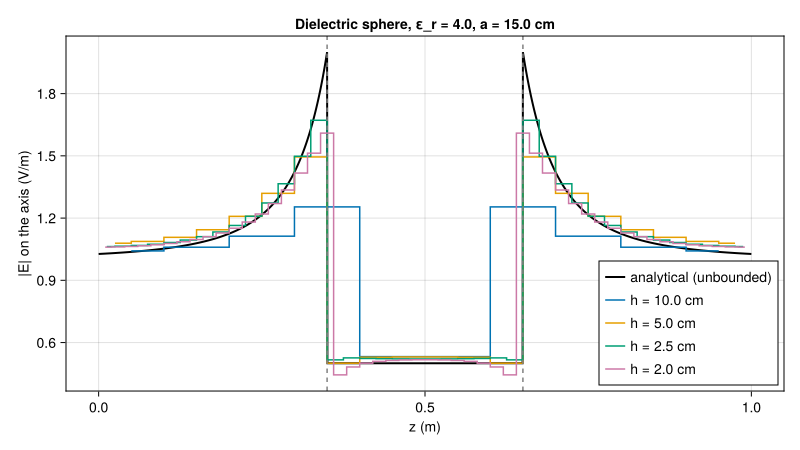

In [5]:
function analytic_axis(z)
    ζ = abs(z - 0.5)
    ζ < a ? E_in : E0 * (1 + 2 * (ε_r - 1) / (ε_r + 2) * a^3 / ζ^3)
end

fig = Figure(size = (800, 450))
ax = Axis(fig[1, 1]; xlabel = "z (m)", ylabel = "|E| on the axis (V/m)",
          title = "Dielectric sphere, ε_r = $ε_r, a = $(100a) cm")
zs = range(0, 1; length = 2001)
lines!(ax, zs, analytic_axis.(zs); color = :black, linewidth = 2, label = "analytical (unbounded)")
for h in (0.1, 0.05, 0.025, 0.02)
    z, E = axis_field(results[h]...)
    stairs!(ax, z, E; step = :center, label = "h = $(round(100h; digits = 1)) cm")
end
vlines!(ax, [0.5 - a, 0.5 + a]; color = :gray, linestyle = :dash)
axislegend(ax; position = :rb)
fig

**The field in the cross-section.** The field component $E_z$ on the plane $y = 0.5\;\text{m}$
through the centre, on the coarsest and the finest grid, with the exact sphere as a dashed
circle. Inside the sphere the field is weaker, and at its poles the dipole raises it. On the
coarse grid the sphere is a blocky body of a few cells; on the fine grid it follows the circle.

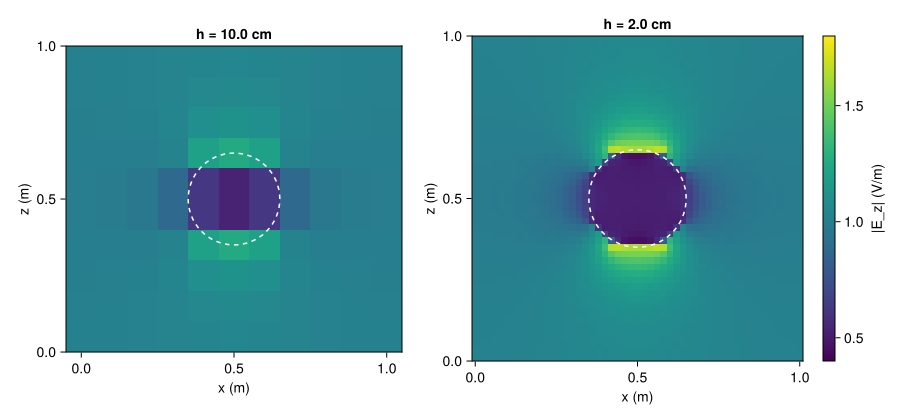

In [6]:
# E_z on the plane y = 0.5 m: the voltage across each z-edge in that plane over its length.
# Node p = i + (j-1)Nu + (k-1)NuNv, so reshape gives Φ[i, j, k].
function Ez_plane(domain, Φ)
    j0 = argmin(abs.(domain.nodes_v .- 0.5))
    P  = reshape(Φ, domain.Nu, domain.Nv, domain.Nw)
    Ez = (P[:, j0, 2:end] .- P[:, j0, 1:end-1]) ./ domain.edges_w'
    return domain.nodes_u, domain.edges_w_center, Ez
end

fig = Figure(size = (900, 420))
for (col, h) in enumerate((0.1, 0.02))
    x, z, Ez = Ez_plane(results[h]...)
    ax = Axis(fig[1, col]; title = "h = $(round(100h; digits = 1)) cm",
              xlabel = "x (m)", ylabel = "z (m)", aspect = DataAspect())
    hm = heatmap!(ax, x, z, Ez; colorrange = (0.4, 1.8), colormap = :viridis)
    lines!(ax, Circle(Point2f(0.5, 0.5), Float32(a)); color = :white, linestyle = :dash)
    col == 2 && Colorbar(fig[1, 3], hm; label = "|E_z| (V/m)")
end
fig

**Discussion.**

- The error does not fall smoothly with $h$. The staircase sphere is sometimes smaller and
  sometimes larger than the real one (see the last column of the table), and the field
  follows. This is typical for curved boundaries on a Cartesian grid: the error decreases on
  average, but not monotonically.
- At $h = 2\;\text{cm}$ the field inside is still about 2 % above $E_\text{in}$, and finer
  grids hardly reduce this. It is the finite box, not the grid: the plates and side walls are
  only about three radii away from the sphere, while the analytical solution assumes them at
  infinity. A larger box reduces this part of the error, at the cost of more nodes.
- Right at the surface, single cells over- or undershoot (the dips just inside the sphere in
  the axis plot). There the staircase cuts through the cells that the field is evaluated in.
- Both problems point to a non-equidistant grid: fine around the sphere, coarse towards the
  walls of a larger box. `change_resolution(coarse, Edges_U, Edges_V, Edges_W)` takes such
  cell widths directly.